In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

In [2]:
RAW_PATH = "../data/raw/complaints.csv"

cols_needed = [
    'Complaint ID', 'Product', 'Issue', 'Sub-issue',
    'Company', 'State', 'Date received', 'Consumer complaint narrative'
]

df = pd.read_csv(RAW_PATH, usecols=cols_needed, low_memory=True)
print(df.shape)
df.head()

(9609797, 8)


,Date received,Product,Issue,Sub-issue,Consumer complaint narrative,Company,State,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer reports,Incorrect information on your report,Information belongs to someone else,NaN,Experian Information Solutions Inc.,FL,14195687
1,2025-06-20,Debt collection,Attempts to collect debt not owed,Debt is not yours,NaN,"Eastern Account Systems of Connecticut, Inc.",FL,14195688
2,2025-06-20,Credit reporting or other personal consumer reports,Improper use of your report,Reporting company used your report improperly,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,14195689
3,2025-06-20,Credit reporting or other personal consumer reports,Improper use of your report,Reporting company used your report improperly,NaN,Experian Information Solutions Inc.,AZ,14195690
4,2025-06-20,Credit reporting or other personal consumer reports,Incorrect information on your report,Account status incorrect,NaN,Experian Information Solutions Inc.,IL,14195692


In [3]:
df.info()
df.columns.tolist()

<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 8 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Issue                         str  
 3   Sub-issue                     str  
 4   Consumer complaint narrative  str  
 5   Company                       str  
 6   State                         str  
 7   Complaint ID                  int64
dtypes: int64(1), str(7)
memory usage: 586.5 MB


['Date received',
 'Product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company',
 'State',
 'Complaint ID']

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

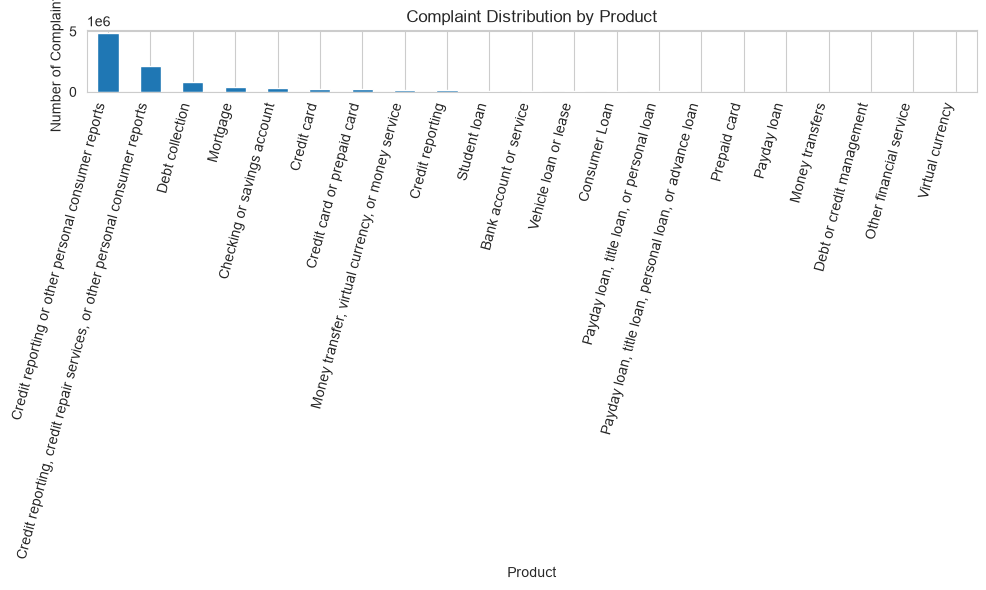

In [4]:
product_counts = df['Product'].value_counts()
print(product_counts)

plt.figure(figsize=(10, 6))
product_counts.plot(kind='bar')
plt.title('Complaint Distribution by Product')
plt.xlabel('Product')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [5]:
has_narrative = df['Consumer complaint narrative'].notna().sum()
no_narrative = df['Consumer complaint narrative'].isna().sum()

print(f"With narrative: {has_narrative}")
print(f"Without narrative: {no_narrative}")
print(f"Percentage with narrative: {has_narrative / len(df) * 100:.2f}%")

With narrative: 2980756
Without narrative: 6629041
Percentage with narrative: 31.02%


count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: word_count, dtype: float64


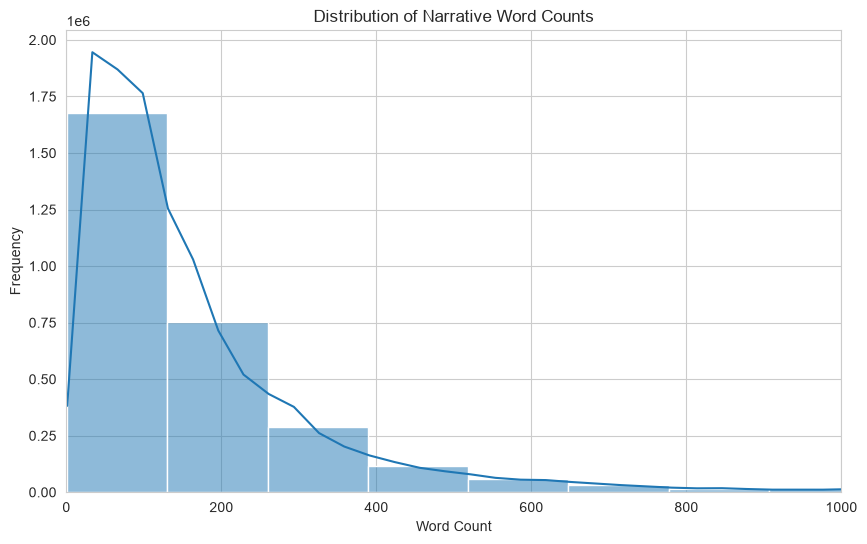

Very short (<5 words): 3175
Very long (>1000 words): 32428


In [7]:
narrative_df = df[df['Consumer complaint narrative'].notna()].copy()
narrative_df['word_count'] = narrative_df['Consumer complaint narrative'].str.count(r'\S+')

print(narrative_df['word_count'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(narrative_df['word_count'], bins=50, kde=True)
plt.title('Distribution of Narrative Word Counts')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, 1000)
plt.show()

# Flag very short / very long narratives
very_short = (narrative_df['word_count'] < 5).sum()
very_long = (narrative_df['word_count'] > 1000).sum()
print(f"Very short (<5 words): {very_short}")
print(f"Very long (>1000 words): {very_long}")

In [8]:
TARGET_PRODUCTS = ['Credit card', 'Personal loan', 'Savings account', 'Money transfer']

# CFPB product names are messy — inspect close matches first
print(df['Product'].unique())

<StringArray>
[                         'Credit reporting or other personal consumer reports',
                                                              'Debt collection',
                                                                  'Credit card',
                                                  'Checking or savings account',
                           'Money transfer, virtual currency, or money service',
                                                        'Vehicle loan or lease',
                                                    'Debt or credit management',
                                                                     'Mortgage',
                      'Payday loan, title loan, personal loan, or advance loan',
                                                                 'Prepaid card',
                                                                 'Student loan',
                                                             'Credit reporting',
 'Credit repor

In [9]:
# Adjust this mapping after inspecting unique values in Cell 7
product_map = {
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Consumer Loan': 'Personal Loan',
    'Checking or savings account': 'Savings Account',
    'Money transfer, virtual currency, or money service': 'Money Transfer',
    'Money transfers': 'Money Transfer',
}

df['product_category'] = df['Product'].map(product_map)
filtered_df = df[df['product_category'].notna()].copy()
filtered_df = filtered_df[filtered_df['Consumer complaint narrative'].notna()].copy()

print(filtered_df['product_category'].value_counts())
print(f"Filtered shape: {filtered_df.shape}")

product_category
Credit Card        189334
Savings Account    140319
Money Transfer      98685
Personal Loan       26699
Name: count, dtype: int64
Filtered shape: (455037, 9)


In [10]:
def clean_narrative(text):
    text = text.lower()
    # remove common boilerplate openers
    boilerplate_patterns = [
        r"i am writing to file a complaint.*?\.",
        r"this is a complaint regarding.*?\.",
        r"to whom it may concern,?",
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, '', text, flags=re.IGNORECASE)
    # remove redaction placeholders like XX/XX/XXXX or XXXX
    text = re.sub(r'x{2,}', '', text)
    # remove special characters, keep basic punctuation
    text = re.sub(r'[^a-z0-9\s\.\,\?\!\']', ' ', text)
    # collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

filtered_df['cleaned_narrative'] = filtered_df['Consumer complaint narrative'].apply(clean_narrative)
filtered_df[['Consumer complaint narrative', 'cleaned_narrative']].head()

,Consumer complaint narrative,cleaned_narrative
12237,A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX that an...,a card was opened under my name by a fraudster. i received a notice from that an account was jus...
12532,I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine o...,i made the mistake of using my wellsfargo debit card to depsit funds into atm machine outside th...
13280,"Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I h...","dear cfpb, i have a secured credit card with citibank which is changed to unsecured card and i h..."
13506,"I have a Citi rewards cards. The credit balance issued to me was {$8400.00}. I recently moved, w...","i have a citi rewards cards. the credit balance issued to me was 8400.00 . i recently moved, whi..."
13955,b'I am writing to dispute the following charges on my CITI Credit Card Accounts where I have bec...,b'i am writing to dispute the following charges on my citi credit card accounts where i have bec...


In [11]:
output_cols = ['Complaint ID', 'product_category', 'Product', 'Issue', 'Sub-issue',
               'Company', 'State', 'Date received', 'cleaned_narrative']

final_df = filtered_df[[c for c in output_cols if c in filtered_df.columns]].copy()
final_df.to_csv('../data/processed/filtered_complaints.csv', index=False)
print(f"Saved {len(final_df)} rows to data/processed/filtered_complaints.csv")

Saved 455037 rows to data/processed/filtered_complaints.csv
